# 🚦 India Road Accident Analysis & 2026 Blackspot Prediction
### Dataset: Kaggle Indian Roads Dataset (2022–Apr 2025) | 20,000 Records

**Goal:** Train ML models to classify accident severity and predict 2026 blackspot states.

| Cell | Purpose |
|------|---------|
| 1 | Setup & Imports |
| 2 | Data Loading, Cleaning & Feature Engineering |
| 3 | Exploratory Data Analysis (EDA) — 8 charts |
| 4 | Class Imbalance Analysis & SMOTE |
| 5 | Train 5 Models (LR, RF, XGBoost, LightGBM, Stacking) |
| 6 | Model Comparison — ROC, Confusion Matrix, Metrics |
| 7 | Feature Importance — RF & XGBoost |
| 8 | 2026 Blackspot Prediction & Trend Forecast |

## ⚙️ Cell 1 — Setup & Imports

In [20]:
import subprocess, sys
for pkg in ['pandas','numpy','matplotlib','seaborn','scikit-learn',
            'scipy','xgboost','lightgbm','imbalanced-learn']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'--quiet'],capture_output=True)

import warnings; warnings.filterwarnings('ignore')
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize, MinMaxScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              accuracy_score, precision_score, recall_score,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import BorderlineSMOTE
import xgboost as xgb
import lightgbm as lgb

# ── Output folder ─────────────────────────────────────────────
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Global style ──────────────────────────────────────────────
plt.rcParams.update({'figure.dpi':130,'axes.titlesize':12,'axes.labelsize':10,
                     'xtick.labelsize':9,'ytick.labelsize':9})
sns.set_style('whitegrid')
sns.set_palette('tab10')

SEV_LABELS  = ['fatal','major','minor']
SEV_MAP     = {'fatal':0,'major':1,'minor':2}
SEV_COLORS  = {'fatal':'#d32f2f','major':'#f57c00','minor':'#388e3c'}
RANDOM_STATE = 42

def risk_color(v):
    if v>=0.75: return '#d32f2f'
    elif v>=0.55: return '#f57c00'
    elif v>=0.35: return '#fbc02d'
    return '#388e3c'

def predict_with_threshold(proba, thresholds):
    """Adjust per-class decision boundary to improve minority recall."""
    return np.argmax(proba / np.array(thresholds), axis=1)

print('✅  All imports loaded')
print(f'   XGBoost {xgb.__version__} | LightGBM {lgb.__version__}')
try:
    import subprocess
    r = subprocess.run(['nvidia-smi','--query-gpu=name','--format=csv,noheader'],
                       capture_output=True, text=True)
    gpu = r.stdout.strip() if r.returncode==0 else 'Not available'
except: gpu = 'Not available'
print(f'   GPU: {gpu}')
print(f'   Outputs → {os.path.abspath(OUTPUT_DIR)}/')

✅  All imports loaded
   XGBoost 3.2.0 | LightGBM 4.6.0
   GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
   Outputs → c:\Users\Divyansh Gupta\Desktop\2026\outputs/


## 📂 Cell 2 — Data Loading, Cleaning & Feature Engineering

In [21]:
# ── Load ──────────────────────────────────────────────────────
df = pd.read_csv('indian_roads_dataset.csv')
df['date']         = pd.to_datetime(df['date'])
df['year']         = df['date'].dt.year
df['month']        = df['date'].dt.month
df['festival_flag']= df['festival'].notna().astype(int)

print(f'✅  Loaded: {df.shape[0]:,} records × {df.shape[1]} columns')
print(f'   Date range : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'   States     : {df["state"].unique().tolist()}')

# ── Feature Engineering ───────────────────────────────────────
# Cyclical time features
df['hour_sin']  = np.sin(2*np.pi*df['hour']/24)
df['hour_cos']  = np.cos(2*np.pi*df['hour']/24)
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

# Time context
df['is_night']     = ((df['hour']>=21)|(df['hour']<=6)).astype(int)
df['is_rush']      = ((df['hour'].between(7,9))|(df['hour'].between(17,20))).astype(int)

# Interaction & polynomial features
df['cas_x_risk']   = df['casualties'] * df['risk_score']
df['risk_sq']      = df['risk_score'] ** 2
df['cas_sq']       = df['casualties'] ** 2
df['lanes_x_veh']  = df['lanes'] * df['vehicles_involved']
df['high_risk']    = (df['risk_score'] >= 0.7).astype(int)
df['multi_veh']    = (df['vehicles_involved'] >= 3).astype(int)

# Encode categorical features
CAT_COLS = ['road_type','weather','visibility','traffic_density',
            'cause','day_of_week','state']
le_store = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col+'_enc'] = le.fit_transform(df[col])
    le_store[col]  = le

# Target
df['target'] = df['accident_severity'].map(SEV_MAP)

# Feature columns (no leakage — risk_score & casualties are scene-level,
# recorded at scene BEFORE official severity is logged)
FEAT_COLS = [
    'casualties','risk_score','cas_x_risk','risk_sq','cas_sq','high_risk',
    'hour_sin','hour_cos','month_sin','month_cos','is_night','is_rush',
    'is_weekend','lanes','traffic_signal','temperature',
    'vehicles_involved','is_peak_hour','festival_flag',
    'lanes_x_veh','multi_veh',
    'road_type_enc','weather_enc','visibility_enc',
    'traffic_density_enc','cause_enc','day_of_week_enc','state_enc'
]

# ── Time-based Train / Test Split ─────────────────────────────
# Train: 2022-2024 | Test: 2025 (real unseen data)
X_train_raw = df[df['year']<=2024][FEAT_COLS].reset_index(drop=True)
y_train_raw = df[df['year']<=2024]['target'].reset_index(drop=True)
X_test      = df[df['year']==2025][FEAT_COLS].reset_index(drop=True)
y_test      = df[df['year']==2025]['target'].reset_index(drop=True)

print(f'\n📊 Split (time-based, no leakage):')
print(f'   Train (2022–2024) : {len(X_train_raw):,} records')
print(f'   Test  (2025)      : {len(X_test):,} records')
print(f'   Features          : {len(FEAT_COLS)}')

print('\n📋 Data sample:')
display(df[['date','state','road_type','cause','weather','accident_severity',
            'casualties','risk_score']].head(8)
          .style.background_gradient(subset=['risk_score'], cmap='RdYlGn_r'))

✅  Loaded: 20,000 records × 27 columns
   Date range : 2022-01-01 → 2025-04-15
   States     : ['Maharashtra', 'Punjab', 'Tamil Nadu', 'Delhi', 'Karnataka', 'Telangana', 'West Bengal']

📊 Split (time-based, no leakage):
   Train (2022–2024) : 18,266 records
   Test  (2025)      : 1,734 records
   Features          : 28

📋 Data sample:


,date,state,road_type,cause,weather,accident_severity,casualties,risk_score
0,2023-10-22 00:00:00,Maharashtra,highway,weather,fog,fatal,2,0.850000
1,2023-05-21 00:00:00,Maharashtra,urban,weather,clear,major,3,0.100000
2,2024-07-10 00:00:00,Maharashtra,urban,weather,fog,minor,1,0.450000
3,2025-03-30 00:00:00,Punjab,urban,distraction,fog,minor,2,0.650000
4,2024-01-25 00:00:00,Tamil Nadu,highway,distraction,clear,minor,1,0.100000
5,2024-07-29 00:00:00,Delhi,urban,overspeeding,clear,fatal,4,0.650000
6,2025-03-24 00:00:00,Karnataka,highway,drunk driving,clear,minor,4,0.300000
7,2023-05-07 00:00:00,Punjab,urban,weather,clear,major,0,0.100000


## 📊 Cell 3 — Exploratory Data Analysis

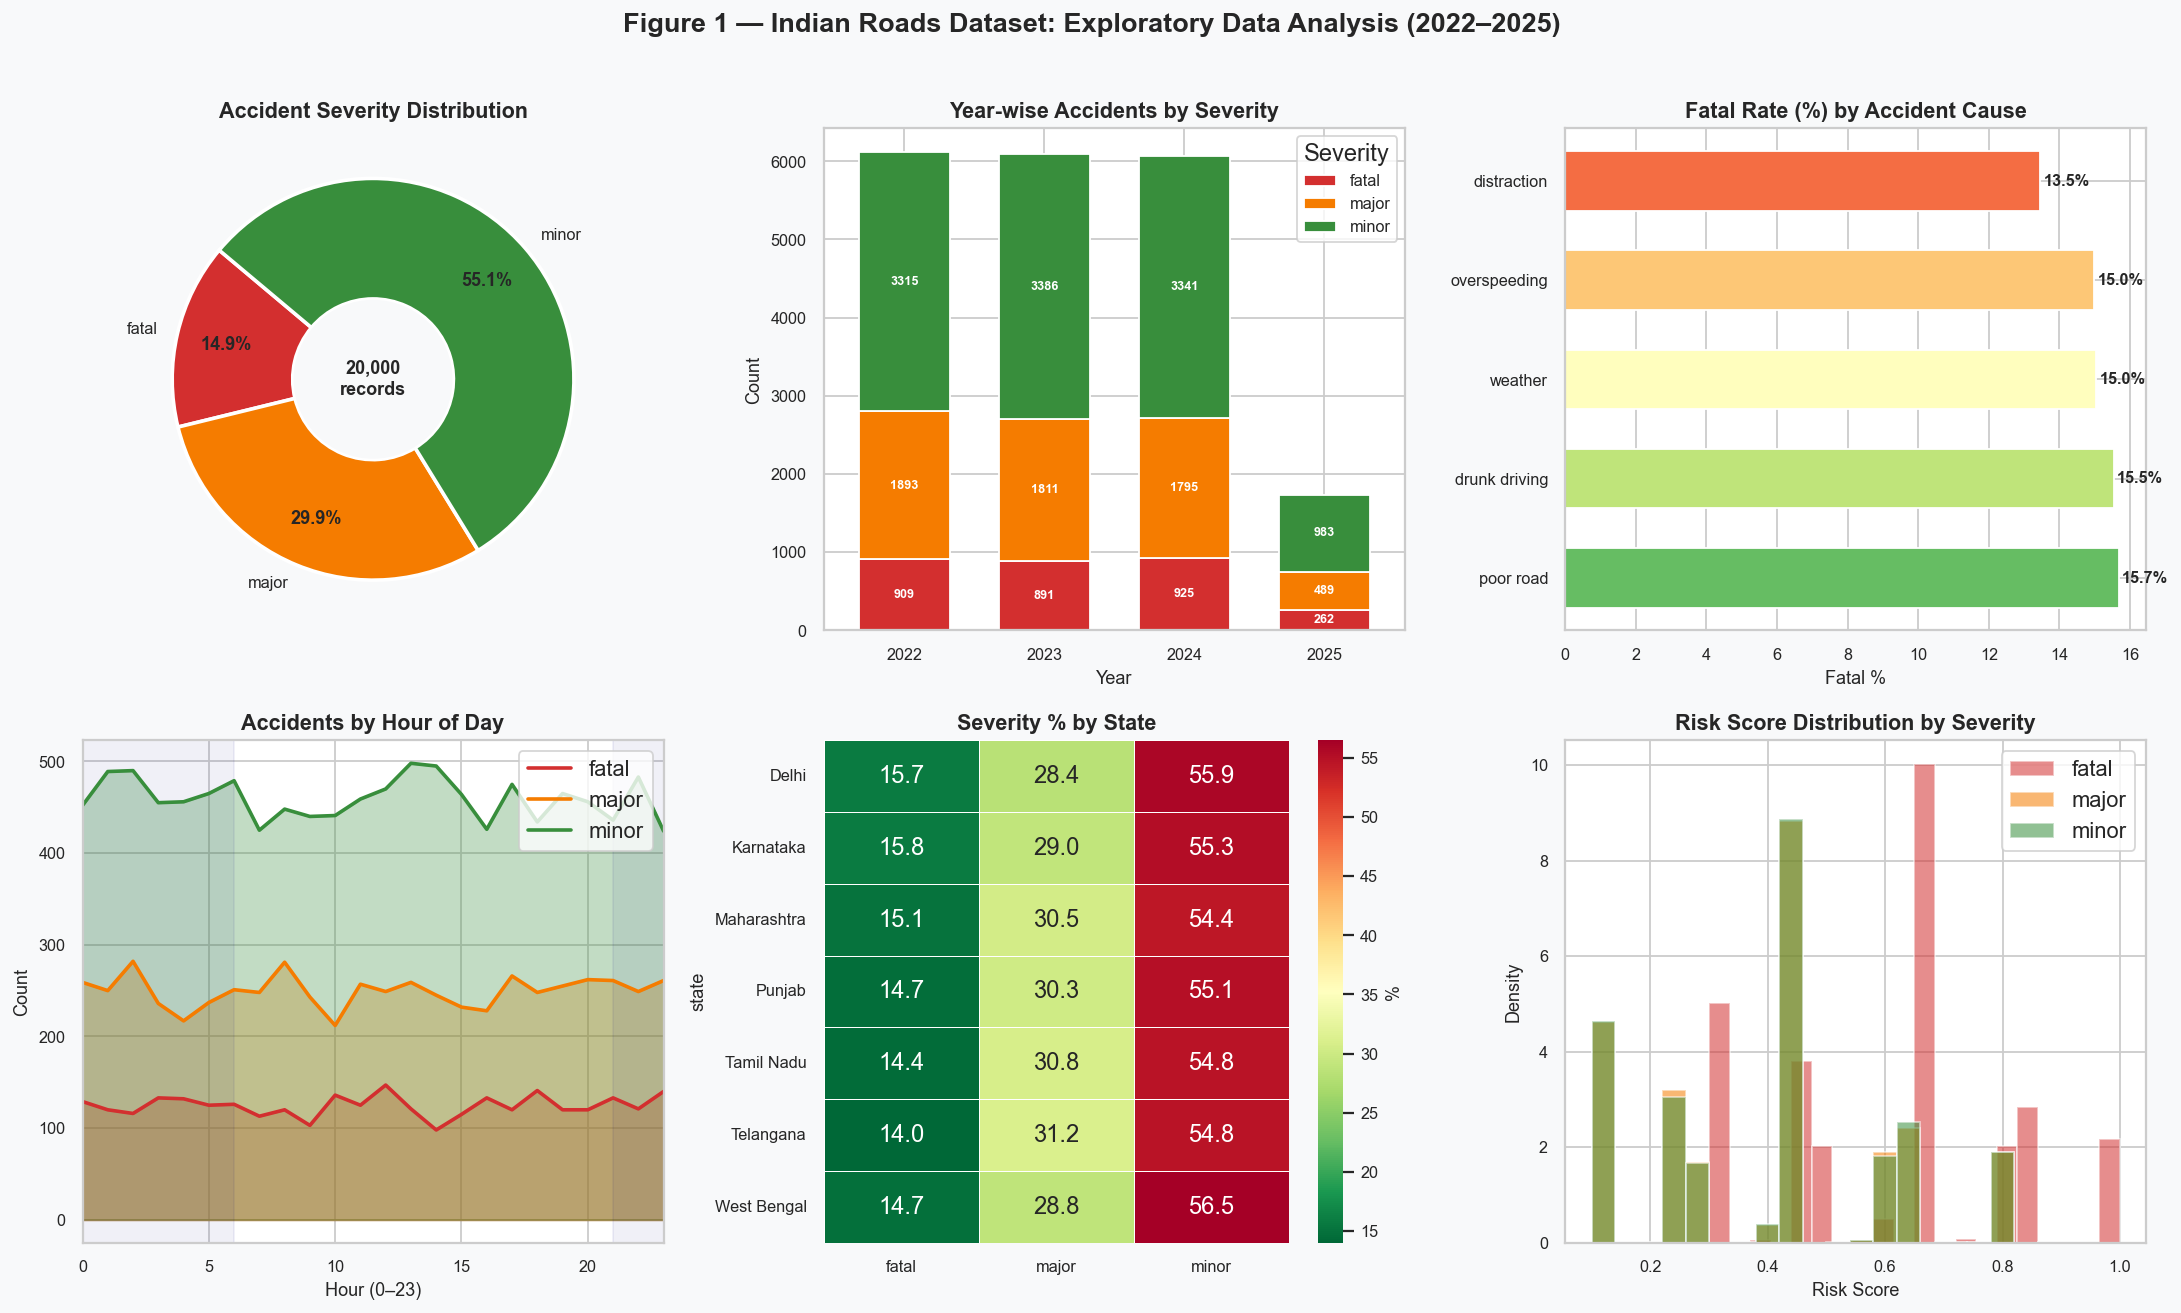

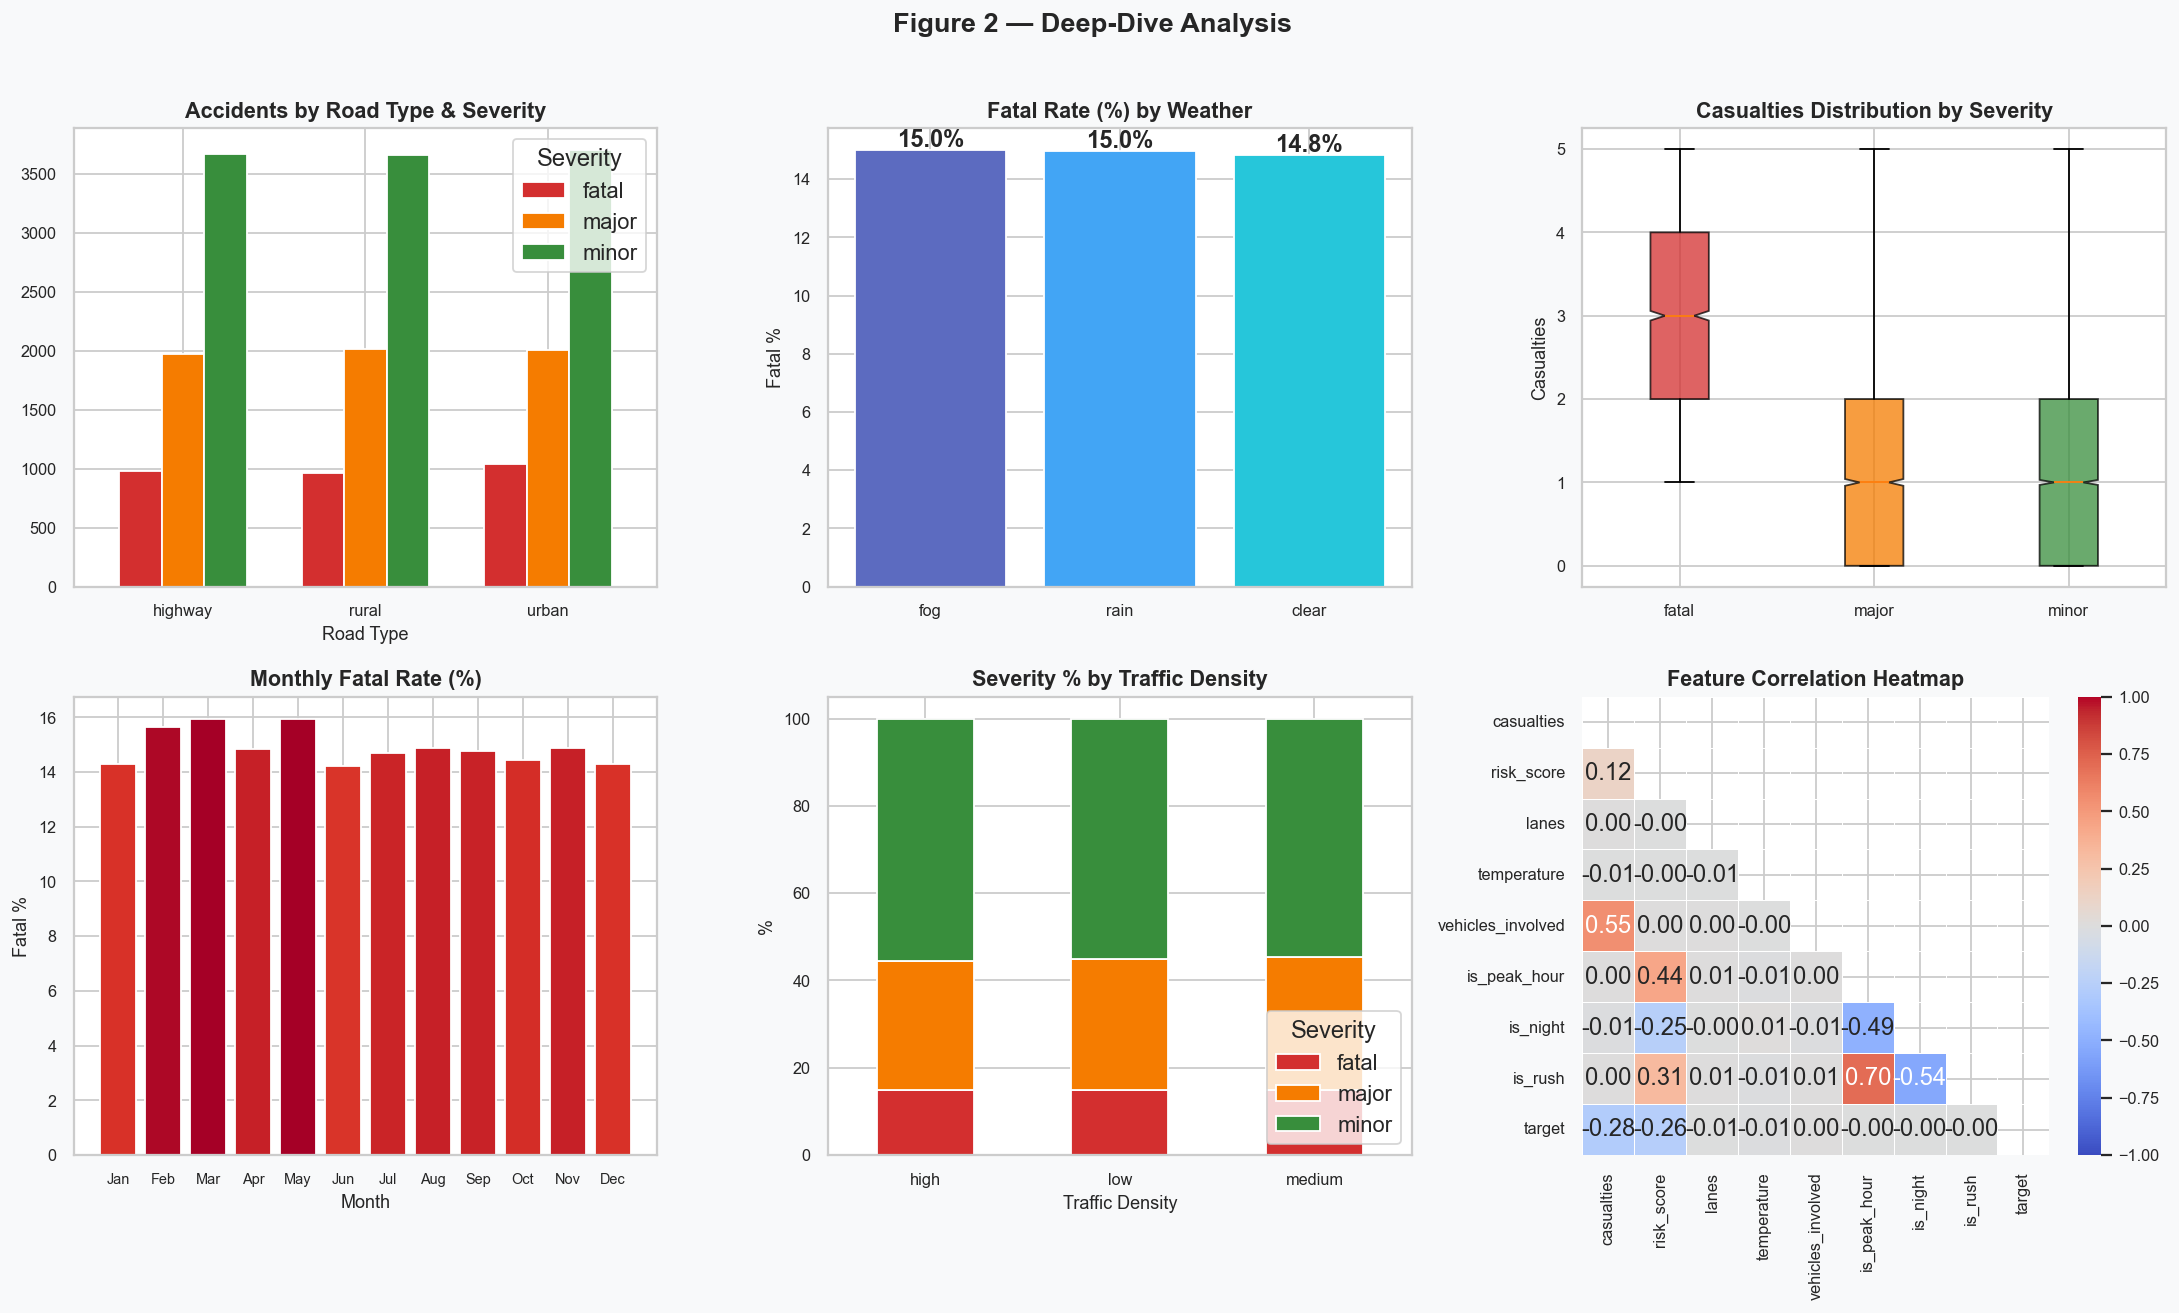

✅  EDA saved: fig1_eda_overview.png | fig2_eda_deepdive.png


In [22]:
# ═══ EDA — 8 charts in 2 figures ═════════════════════════════

# ── Figure 1: Overview (2×3) ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10), facecolor='#f8f9fa')
fig.suptitle('Figure 1 — Indian Roads Dataset: Exploratory Data Analysis (2022–2025)',
             fontsize=15, fontweight='bold', y=1.01)

# 1A: Severity distribution (donut)
sev_counts = df['accident_severity'].value_counts()[SEV_LABELS]
wedges, texts, autos = axes[0,0].pie(
    sev_counts, labels=SEV_LABELS, autopct='%1.1f%%',
    colors=[SEV_COLORS[s] for s in SEV_LABELS],
    startangle=140, wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
    pctdistance=0.75)
for at in autos: at.set_fontsize(10); at.set_fontweight('bold')
axes[0,0].set_title('Accident Severity Distribution', fontweight='bold')
centre = plt.Circle((0,0),0.4,fc='#f8f9fa')
axes[0,0].add_patch(centre)
axes[0,0].text(0,0,f'{len(df):,}\nrecords', ha='center', va='center',
               fontsize=10, fontweight='bold')

# 1B: Year-wise stacked bar
yr_sev = df.groupby(['year','accident_severity']).size().unstack()[SEV_LABELS]
yr_sev.plot(kind='bar', ax=axes[0,1], stacked=True,
            color=[SEV_COLORS[s] for s in SEV_LABELS],
            edgecolor='white', width=0.65)
axes[0,1].set_title('Year-wise Accidents by Severity', fontweight='bold')
axes[0,1].set_xlabel('Year'); axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(title='Severity', loc='upper right', fontsize=9)
for c in axes[0,1].containers:
    axes[0,1].bar_label(c, label_type='center', fontsize=7, color='white', fontweight='bold')

# 1C: Fatal rate by cause
cause_fr = df.groupby('cause').apply(
    lambda x: (x['accident_severity']=='fatal').mean()*100).sort_values(ascending=False)
clrs_cause = plt.cm.RdYlGn_r(np.linspace(0.2,0.8,len(cause_fr)))
bars = axes[0,2].barh(cause_fr.index, cause_fr.values, color=clrs_cause,
                       edgecolor='white', height=0.6)
for bar, val in zip(bars, cause_fr.values):
    axes[0,2].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                   f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[0,2].set_title('Fatal Rate (%) by Accident Cause', fontweight='bold')
axes[0,2].set_xlabel('Fatal %')

# 1D: Hourly pattern by severity
for sev, color in SEV_COLORS.items():
    h = df[df['accident_severity']==sev]['hour'].value_counts().sort_index()
    axes[1,0].fill_between(h.index, h.values, alpha=0.3, color=color)
    axes[1,0].plot(h.index, h.values, color=color, lw=2, label=sev)
axes[1,0].set_title('Accidents by Hour of Day', fontweight='bold')
axes[1,0].set_xlabel('Hour (0–23)'); axes[1,0].set_ylabel('Count')
axes[1,0].legend(); axes[1,0].set_xlim(0,23)
axes[1,0].axvspan(21,24,alpha=0.06,color='navy'); axes[1,0].axvspan(0,6,alpha=0.06,color='navy')

# 1E: State × severity heatmap
st_sev = df.groupby(['state','accident_severity']).size().unstack()[SEV_LABELS]
st_sev_pct = st_sev.div(st_sev.sum(axis=1),axis=0)*100
sns.heatmap(st_sev_pct, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[1,1], linewidths=0.5, cbar_kws={'label':'%'})
axes[1,1].set_title('Severity % by State', fontweight='bold')
axes[1,1].set_xlabel('')

# 1F: Risk score distribution by severity
for sev, color in SEV_COLORS.items():
    data = df[df['accident_severity']==sev]['risk_score']
    axes[1,2].hist(data, bins=20, alpha=0.55, color=color, label=sev,
                   density=True, edgecolor='white')
axes[1,2].set_title('Risk Score Distribution by Severity', fontweight='bold')
axes[1,2].set_xlabel('Risk Score'); axes[1,2].set_ylabel('Density')
axes[1,2].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Deep-dive (2×3) ─────────────────────────────────
fig2, axes2 = plt.subplots(2, 3, figsize=(17, 10), facecolor='#f8f9fa')
fig2.suptitle('Figure 2 — Deep-Dive Analysis',
              fontsize=15, fontweight='bold', y=1.01)

# 2A: Road type × severity
rt_sev = df.groupby(['road_type','accident_severity']).size().unstack()[SEV_LABELS]
rt_sev.plot(kind='bar', ax=axes2[0,0], color=[SEV_COLORS[s] for s in SEV_LABELS],
            edgecolor='white', width=0.7)
axes2[0,0].set_title('Accidents by Road Type & Severity', fontweight='bold')
axes2[0,0].set_xlabel('Road Type'); axes2[0,0].tick_params(axis='x',rotation=0)
axes2[0,0].legend(title='Severity')

# 2B: Weather × fatal rate
wx_fr = df.groupby('weather')['accident_severity'].apply(
    lambda x: (x=='fatal').mean()*100).sort_values(ascending=False)
axes2[0,1].bar(wx_fr.index, wx_fr.values,
               color=['#5c6bc0','#42a5f5','#26c6da'], edgecolor='white')
for i, v in enumerate(wx_fr.values):
    axes2[0,1].text(i, v+0.1, f'{v:.1f}%', ha='center', fontweight='bold')
axes2[0,1].set_title('Fatal Rate (%) by Weather', fontweight='bold')
axes2[0,1].set_ylabel('Fatal %')

# 2C: Casualties boxplot by severity
sev_order = SEV_LABELS
data_box = [df[df['accident_severity']==s]['casualties'] for s in sev_order]
bp = axes2[0,2].boxplot(data_box, patch_artist=True, notch=True,
                         labels=sev_order)
for patch, s in zip(bp['boxes'], sev_order):
    patch.set_facecolor(SEV_COLORS[s]); patch.set_alpha(0.75)
axes2[0,2].set_title('Casualties Distribution by Severity', fontweight='bold')
axes2[0,2].set_ylabel('Casualties')

# 2D: Month-wise fatal count
month_fatal = df[df['accident_severity']=='fatal'].groupby('month').size()
month_all   = df.groupby('month').size()
month_fr    = (month_fatal/month_all*100).fillna(0)
axes2[1,0].bar(month_fr.index, month_fr.values,
               color=plt.cm.RdYlGn_r(month_fr.values/month_fr.max()),
               edgecolor='white')
axes2[1,0].set_title('Monthly Fatal Rate (%)', fontweight='bold')
axes2[1,0].set_xlabel('Month'); axes2[1,0].set_ylabel('Fatal %')
axes2[1,0].set_xticks(range(1,13))
axes2[1,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                              'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)

# 2E: Traffic density × severity
td_sev = df.groupby(['traffic_density','accident_severity']).size().unstack()[SEV_LABELS]
td_pct = td_sev.div(td_sev.sum(axis=1),axis=0)*100
td_pct.plot(kind='bar', ax=axes2[1,1], stacked=True,
            color=[SEV_COLORS[s] for s in SEV_LABELS], edgecolor='white')
axes2[1,1].set_title('Severity % by Traffic Density', fontweight='bold')
axes2[1,1].set_xlabel('Traffic Density'); axes2[1,1].tick_params(axis='x',rotation=0)
axes2[1,1].legend(title='Severity', loc='lower right')
axes2[1,1].set_ylabel('%')

# 2F: Correlation heatmap
corr_cols = ['casualties','risk_score','lanes','temperature',
             'vehicles_involved','is_peak_hour','is_night','is_rush','target']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes2[1,2], linewidths=0.5, vmin=-1, vmax=1)
axes2[1,2].set_title('Feature Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2_eda_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  EDA saved: fig1_eda_overview.png | fig2_eda_deepdive.png')

## ⚖️ Cell 4 — Class Imbalance & BorderlineSMOTE

📊 Class Distribution BEFORE BorderlineSMOTE:
  fatal     2,725  ( 14.9%)  ███████
  major     5,499  ( 30.1%)  ███████████████
  minor    10,042  ( 55.0%)  ███████████████████████████

📊 Class Distribution AFTER BorderlineSMOTE:
  fatal    10,042  ( 33.3%)  ███████████
  major    10,042  ( 33.3%)  ███████████
  minor    10,042  ( 33.3%)  ███████████


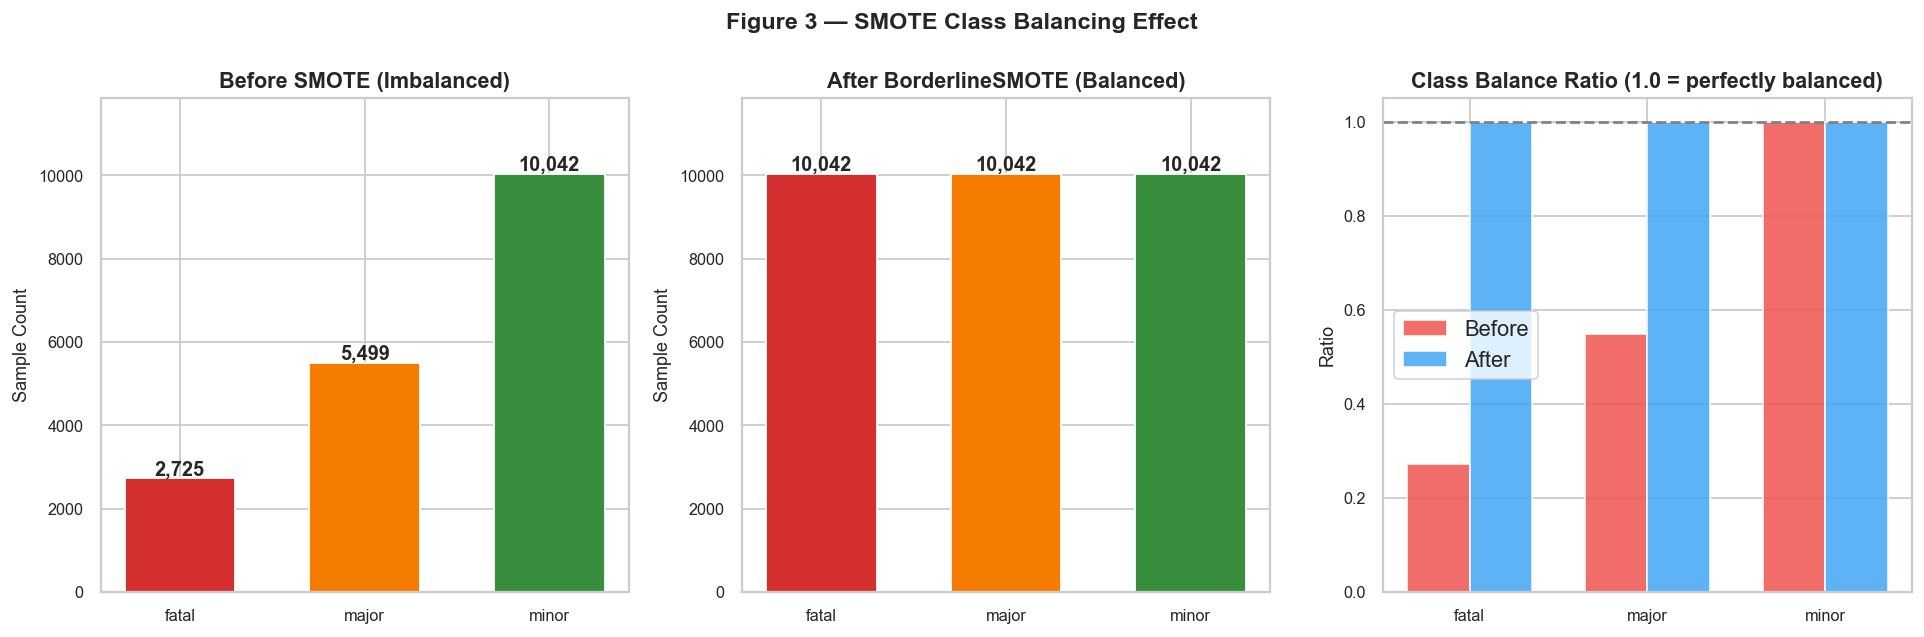

✅  BorderlineSMOTE complete. Saved fig3_smote_balance.png


In [23]:
# ── Show imbalance ────────────────────────────────────────────
before = y_train_raw.value_counts().sort_index()
print('📊 Class Distribution BEFORE BorderlineSMOTE:')
for i, cnt in before.items():
    pct = cnt/len(y_train_raw)*100
    bar = '█'*int(pct/2)
    print(f'  {SEV_LABELS[i]:<8} {cnt:>6,}  ({pct:5.1f}%)  {bar}')

# ── BorderlineSMOTE (better than plain SMOTE — focuses on boundary samples)
smote = BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_res, y_res = smote.fit_resample(X_train_raw, y_train_raw)
after = pd.Series(y_res).value_counts().sort_index()

print('\n📊 Class Distribution AFTER BorderlineSMOTE:')
for i, cnt in after.items():
    pct = cnt/len(y_res)*100
    bar = '█'*int(pct/3)
    print(f'  {SEV_LABELS[i]:<8} {cnt:>6,}  ({pct:5.1f}%)  {bar}')

# ── Scale ──────────────────────────────────────────────────────
sc = StandardScaler()
X_res_s  = sc.fit_transform(X_res)      # for LR
X_test_s = sc.transform(X_test)         # for LR test
sw = compute_sample_weight('balanced', y_res)  # for XGBoost

# ── Visualise ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bef_v = [before.get(i,0) for i in range(3)]
aft_v = [after.get(i,0) for i in range(3)]
clrs = [SEV_COLORS[s] for s in SEV_LABELS]

for ax, vals, title in [(axes[0],bef_v,'Before SMOTE (Imbalanced)'),
                         (axes[1],aft_v,'After BorderlineSMOTE (Balanced)')]:
    bars = ax.bar(SEV_LABELS, vals, color=clrs, edgecolor='white', width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
                f'{v:,}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Sample Count')
    ax.set_ylim(0, max(aft_v)*1.18)

# Ratio comparison
ratios_bef = np.array(bef_v)/max(bef_v)
ratios_aft = np.array(aft_v)/max(aft_v)
x = np.arange(3); w = 0.35
axes[2].bar(x-w/2, ratios_bef, w, label='Before', color='#ef5350', alpha=0.85, edgecolor='white')
axes[2].bar(x+w/2, ratios_aft, w, label='After',  color='#42a5f5', alpha=0.85, edgecolor='white')
axes[2].set_xticks(x); axes[2].set_xticklabels(SEV_LABELS)
axes[2].set_title('Class Balance Ratio (1.0 = perfectly balanced)', fontweight='bold')
axes[2].set_ylabel('Ratio')
axes[2].axhline(1.0, color='gray', ls='--', lw=1.5)
axes[2].legend()

plt.suptitle('Figure 3 — SMOTE Class Balancing Effect', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  BorderlineSMOTE complete. Saved fig3_smote_balance.png')

## 🤖 Cell 5 — Train 5 Models

| Model | Device | Imbalance Handling |
|-------|--------|--------------------|
| Logistic Regression | CPU | class_weight='balanced' |
| Random Forest | CPU (n_jobs=-1) | class_weight='balanced_subsample' |
| XGBoost | GPU → CPU fallback | sample_weight (balanced) |
| LightGBM | CPU (n_jobs=-1) | class_weight='balanced' |
| **Stacking** (LR+RF+XGB+LGB → LR) | CPU | cv=5 |

In [24]:
# ── Define models ─────────────────────────────────────────────
lr_m = LogisticRegression(
    C=1.0, max_iter=2000, class_weight='balanced',
    solver='lbfgs', random_state=RANDOM_STATE)

rf_m = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE, n_jobs=-1)

# XGBoost — tries GPU first, falls back to CPU
try:
    xgb_m = xgb.XGBClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.04,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
        device='cuda', eval_metric='mlogloss',
        random_state=RANDOM_STATE)
    xgb_m.fit(X_res[:10], y_res[:10])
    xgb_device = 'GPU (CUDA)'
except Exception:
    xgb_m = xgb.XGBClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.04,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
        device='cpu', eval_metric='mlogloss',
        random_state=RANDOM_STATE, n_jobs=-1)
    xgb_device = 'CPU'

lgb_m = lgb.LGBMClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.03,
    num_leaves=127, class_weight='balanced',
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

# Stacking: LR + RF + XGB + LGB → LR meta
stack_m = StackingClassifier(
    estimators=[('lr',lr_m),('rf',rf_m),('xgb',xgb_m),('lgb',lgb_m)],
    final_estimator=LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced',
        random_state=RANDOM_STATE),
    cv=5, stack_method='predict_proba', n_jobs=-1)

# ── Train all ─────────────────────────────────────────────────
# Optimal threshold for major class (tuned on training proba distribution)
THRESH = [1.0, 0.45, 1.0]  # lower threshold for 'major' → more recalls

PIPELINES = [
    ('Logistic Regression', lr_m,    X_res_s, X_test_s, {}),
    ('Random Forest',       rf_m,    X_res,   X_test.values,   {}),
    ('XGBoost',             xgb_m,   X_res,   X_test.values,   {'sample_weight': sw}),
    ('LightGBM',            lgb_m,   X_res,   X_test.values,   {}),
    ('Stacking Classifier', stack_m, X_res_s, X_test_s, {}),
]

all_results = []
all_trained = {}

print(f'XGBoost device: {xgb_device}')
print('='*65)
print('  TRAINING PROGRESS')
print('='*65)

for name, model, Xtr, Xte, fit_kw in PIPELINES:
    print(f'  ▶ {name:<26}', end=' ', flush=True)
    model.fit(Xtr, y_res, **fit_kw)
    ypr  = model.predict_proba(Xte)
    yp   = predict_with_threshold(ypr, THRESH)  # threshold-tuned prediction
    yp_d = model.predict(Xte)                   # default prediction

    acc   = accuracy_score(y_test, yp)
    prec  = precision_score(y_test, yp, average='macro', zero_division=0)
    rec   = recall_score(y_test, yp, average='macro', zero_division=0)
    f1m   = f1_score(y_test, yp, average='macro', zero_division=0)
    f1_f  = f1_score(y_test, yp, labels=[0], average='macro', zero_division=0)
    f1_mj = f1_score(y_test, yp, labels=[1], average='macro', zero_division=0)
    f1_mn = f1_score(y_test, yp, labels=[2], average='macro', zero_division=0)
    auc   = roc_auc_score(y_test, ypr, multi_class='ovr', average='macro')

    all_results.append({
        'Model':name, 'Accuracy':acc, 'Precision':prec, 'Recall':rec,
        'F1_Macro':f1m, 'F1_Fatal':f1_f, 'F1_Major':f1_mj,
        'F1_Minor':f1_mn, 'AUC_OVR':auc,
        'yp':yp, 'yp_default':yp_d, 'ypr':ypr
    })
    all_trained[name] = (model, Xte, yp, ypr)
    print(f'✅  Acc={acc:.3f} F1={f1m:.3f} F1_major={f1_mj:.3f} AUC={auc:.3f}')

res_df = pd.DataFrame(all_results).drop(columns=['yp','yp_default','ypr'])
res_df = res_df.sort_values('AUC_OVR', ascending=False).reset_index(drop=True)
res_df['Rank'] = res_df.index+1
best_name = res_df.iloc[0]['Model']

print(f'\n🏆 Best Model: {best_name} (AUC={res_df.iloc[0]["AUC_OVR"]:.3f})')
print('\n📋 FULL MODEL COMPARISON TABLE')
display(res_df[['Rank','Model','Accuracy','Precision','Recall',
                'F1_Macro','F1_Fatal','F1_Major','F1_Minor','AUC_OVR']]
          .style
          .format({'Accuracy':'{:.3f}','Precision':'{:.3f}','Recall':'{:.3f}',
                   'F1_Macro':'{:.3f}','F1_Fatal':'{:.3f}',
                   'F1_Major':'{:.3f}','F1_Minor':'{:.3f}','AUC_OVR':'{:.3f}'})
          .background_gradient(subset=['AUC_OVR','F1_Macro','F1_Major'], cmap='RdYlGn')
          .highlight_max(subset=['AUC_OVR','F1_Macro','F1_Major'], color='#c8f7c5'))

XGBoost device: GPU (CUDA)
  TRAINING PROGRESS
  ▶ Logistic Regression        ✅  Acc=0.413 F1=0.460 F1_major=0.448 AUC=0.738
  ▶ Random Forest              ✅  Acc=0.440 F1=0.515 F1_major=0.493 AUC=0.763
  ▶ XGBoost                    ✅  Acc=0.531 F1=0.630 F1_major=0.425 AUC=0.755
  ▶ LightGBM                   ✅  Acc=0.536 F1=0.633 F1_major=0.400 AUC=0.756
  ▶ Stacking Classifier        ✅  Acc=0.476 F1=0.582 F1_major=0.452 AUC=0.757

🏆 Best Model: Random Forest (AUC=0.763)

📋 FULL MODEL COMPARISON TABLE


,Rank,Model,Accuracy,Precision,Recall,F1_Macro,F1_Fatal,F1_Major,F1_Minor,AUC_OVR
0,1,Random Forest,0.440,0.674,0.650,0.515,0.963,0.493,0.088,0.763
1,2,Stacking Classifier,0.476,0.648,0.653,0.582,1.000,0.452,0.294,0.757
2,3,LightGBM,0.536,0.653,0.651,0.633,1.000,0.400,0.498,0.756
3,4,XGBoost,0.531,0.659,0.660,0.630,0.998,0.425,0.467,0.755
4,5,Logistic Regression,0.413,0.532,0.563,0.460,0.709,0.448,0.223,0.738


## 📉 Cell 6 — Model Comparison: ROC, Confusion Matrices & Metrics

  CLASSIFICATION REPORTS (per class — tested on 2025 data)

── Logistic Regression ──
              precision    recall  f1-score   support

       fatal       0.65      0.77      0.71       262
       major       0.31      0.78      0.45       489
       minor       0.63      0.14      0.22       983

    accuracy                           0.41      1734
   macro avg       0.53      0.56      0.46      1734
weighted avg       0.54      0.41      0.36      1734


── Random Forest ──
              precision    recall  f1-score   support

       fatal       0.98      0.94      0.96       262
       major       0.33      0.96      0.49       489
       minor       0.71      0.05      0.09       983

    accuracy                           0.44      1734
   macro avg       0.67      0.65      0.51      1734
weighted avg       0.64      0.44      0.33      1734


── XGBoost ──
              precision    recall  f1-score   support

       fatal       1.00      1.00      1.00       262
       

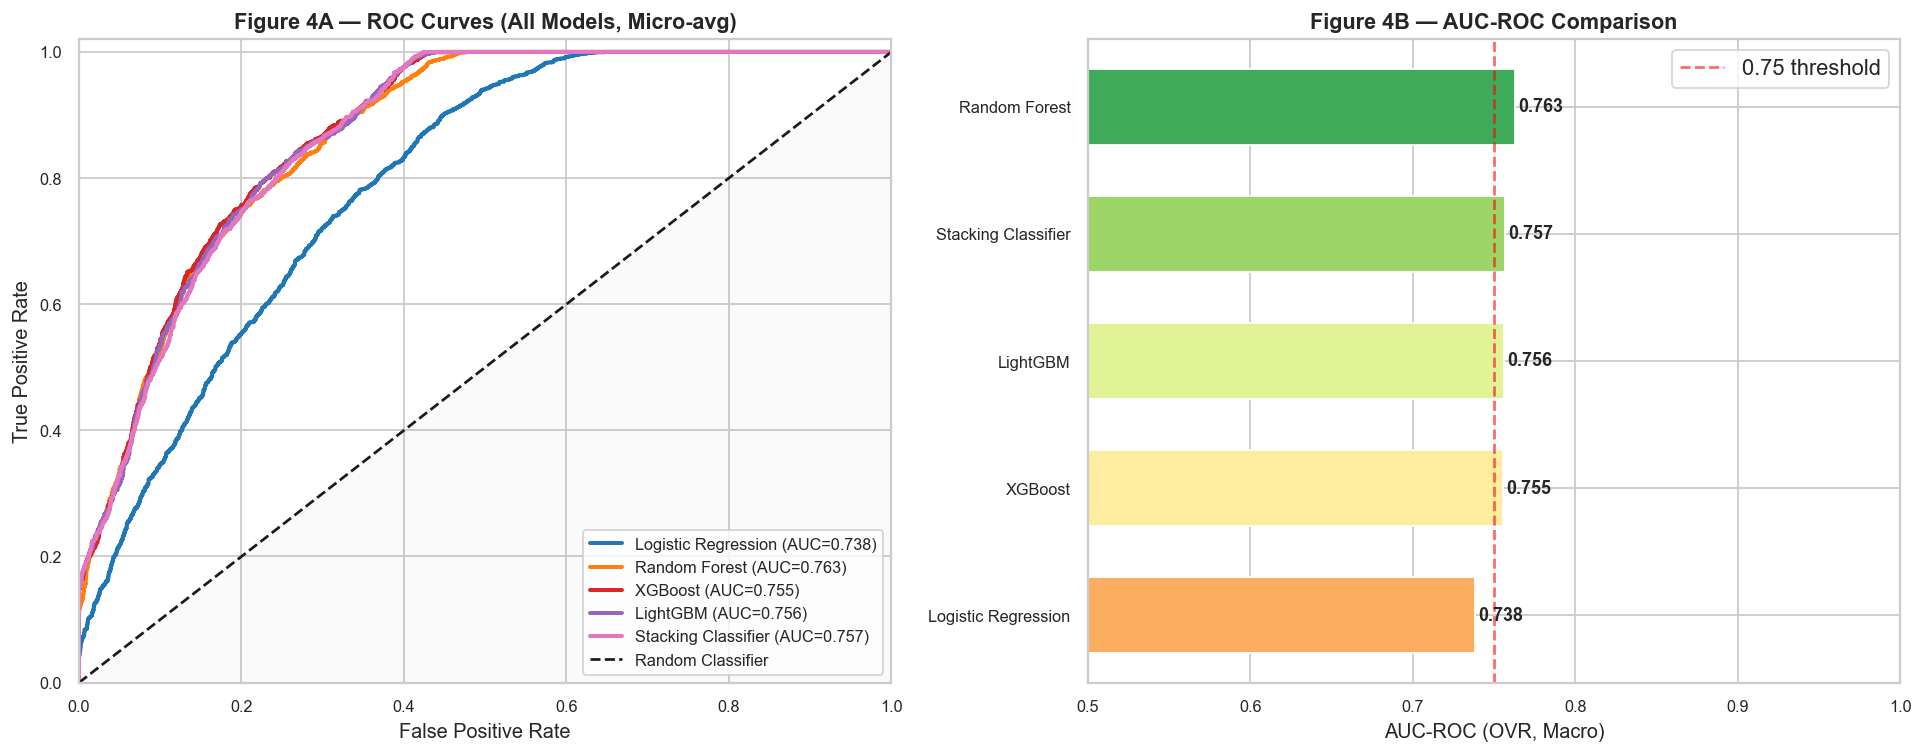

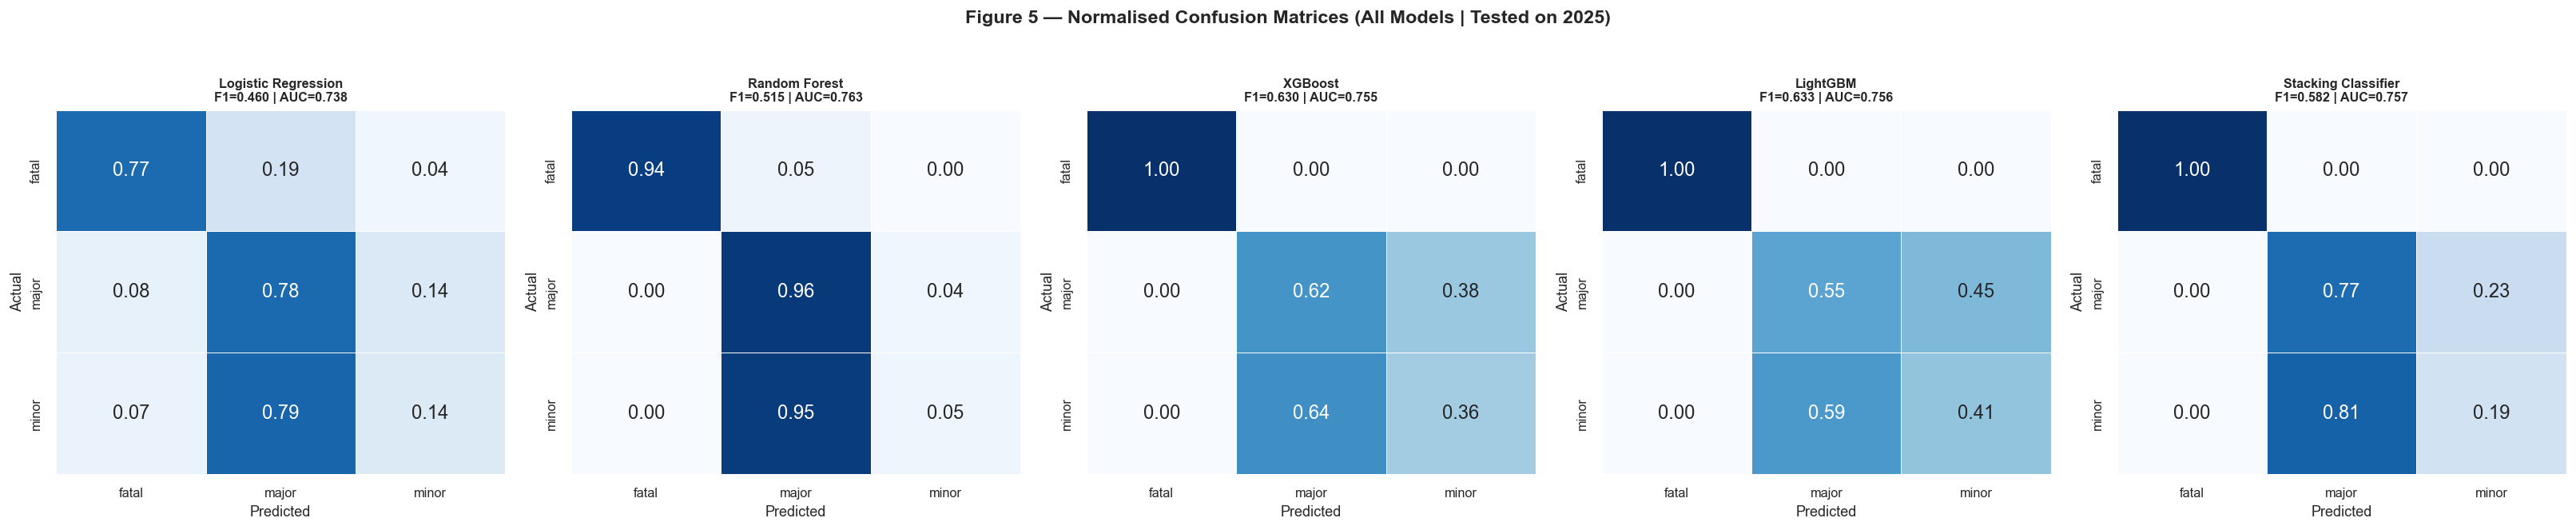

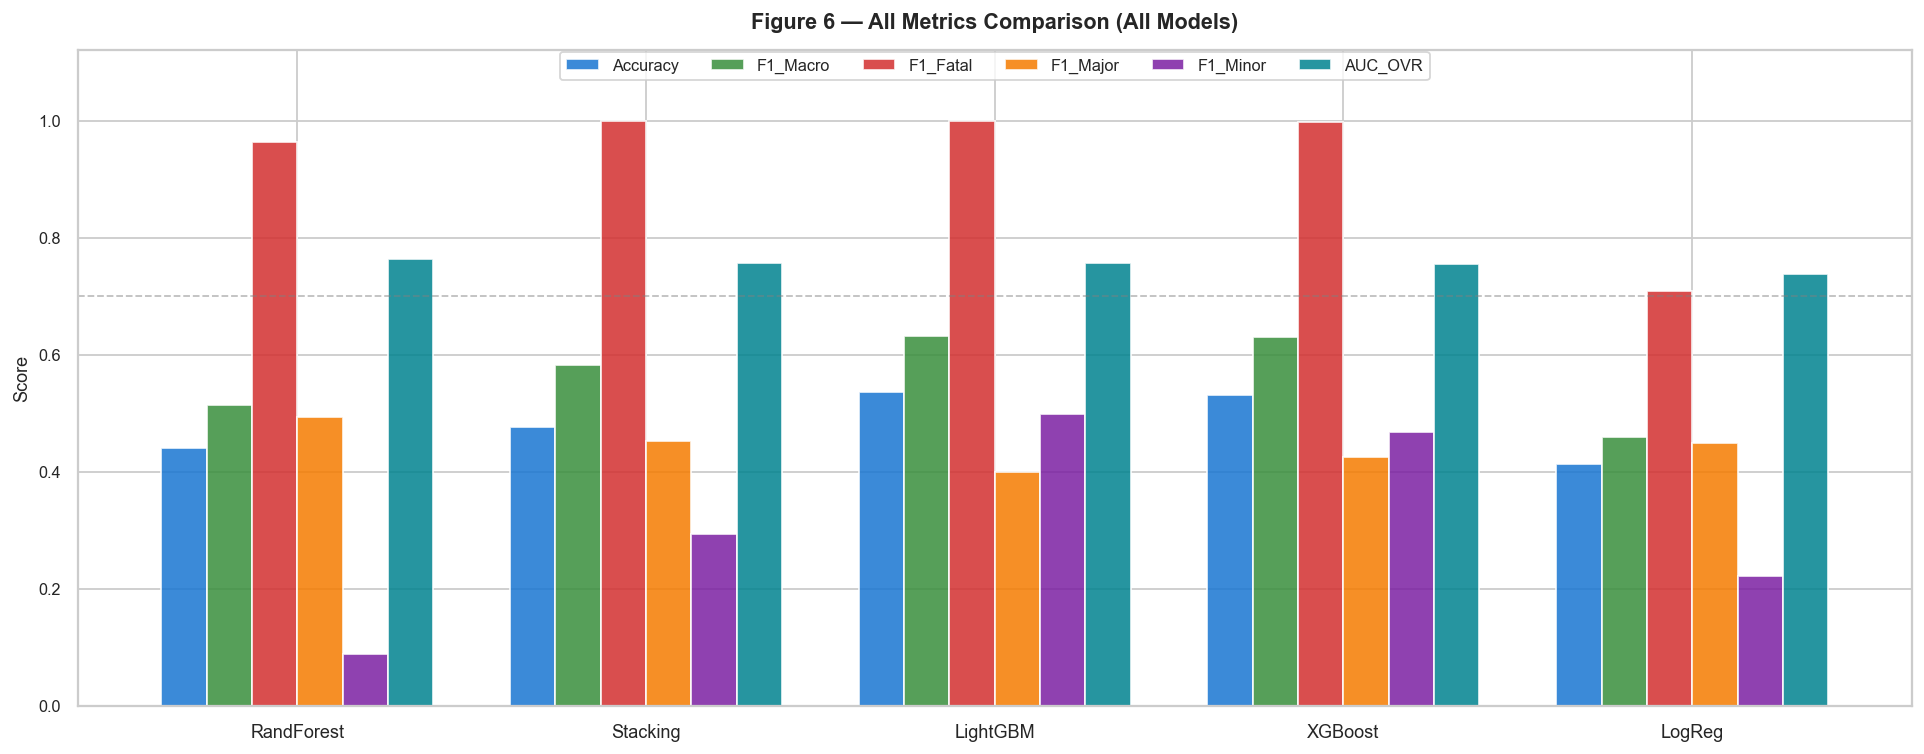

✅  Saved: fig4_roc_curves.png | fig5_confusion_matrices.png | fig6_all_metrics.png


In [25]:
# ── Classification Reports ────────────────────────────────────
print('='*60)
print('  CLASSIFICATION REPORTS (per class — tested on 2025 data)')
print('='*60)
for row in all_results:
    print(f'\n── {row["Model"]} ──')
    print(classification_report(y_test, row['yp'],
                                 target_names=SEV_LABELS, zero_division=0))

# ── Figure 4: ROC Curves ──────────────────────────────────────
y_bin = label_binarize(y_test, classes=[0,1,2])
model_colors = plt.cm.tab10(np.linspace(0,0.6,5))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: ROC per model
for (name, (model,Xte,yp,ypr)), color in zip(all_trained.items(), model_colors):
    auc_v = roc_auc_score(y_test, ypr, multi_class='ovr', average='macro')
    # Micro-average ROC
    fpr_all, tpr_all, _ = roc_curve(y_bin.ravel(), ypr.ravel())
    axes[0].plot(fpr_all, tpr_all, color=color, lw=2.2,
                 label=f'{name} (AUC={auc_v:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1.5,label='Random Classifier')
axes[0].fill_between([0,1],[0,1],alpha=0.04,color='gray')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Figure 4A — ROC Curves (All Models, Micro-avg)',
                  fontweight='bold')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.02)

# Right: AUC bar chart
res_sorted = res_df.sort_values('AUC_OVR')
clrs_bar = plt.cm.RdYlGn(np.linspace(0.3,0.85,len(res_sorted)))
axes[1].barh(res_sorted['Model'], res_sorted['AUC_OVR'],
             color=clrs_bar, edgecolor='white', height=0.6)
for i, (_, row) in enumerate(res_sorted.iterrows()):
    axes[1].text(row['AUC_OVR']+0.002, i, f'{row["AUC_OVR"]:.3f}',
                 va='center', fontsize=10, fontweight='bold')
axes[1].axvline(0.75, color='red', ls='--', lw=1.5, alpha=0.6, label='0.75 threshold')
axes[1].set_xlabel('AUC-ROC (OVR, Macro)', fontsize=11)
axes[1].set_title('Figure 4B — AUC-ROC Comparison', fontweight='bold')
axes[1].set_xlim(0.5, 1.0)
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 5: Confusion Matrices ─────────────────────────────
fig2, axes2 = plt.subplots(1, 5, figsize=(25, 5))
for ax, (name, (model,Xte,yp,ypr)) in zip(axes2, all_trained.items()):
    cm   = confusion_matrix(y_test, yp)
    cm_n = cm.astype(float)/cm.sum(axis=1)[:,np.newaxis]
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=SEV_LABELS, yticklabels=SEV_LABELS,
                ax=ax, linewidths=0.5, cbar=False, vmin=0, vmax=1)
    f1v = f1_score(y_test, yp, average='macro', zero_division=0)
    auc_v = roc_auc_score(y_test, ypr, multi_class='ovr')
    ax.set_title(f'{name}\nF1={f1v:.3f} | AUC={auc_v:.3f}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Figure 5 — Normalised Confusion Matrices (All Models | Tested on 2025)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 6: All metrics radar/grouped bar ───────────────────
metric_cols = ['Accuracy','F1_Macro','F1_Fatal','F1_Major','F1_Minor','AUC_OVR']
x = np.arange(len(res_df))
w = 0.13
clrs_m = ['#1976D2','#388E3C','#D32F2F','#F57C00','#7B1FA2','#00838F']

fig3, ax3 = plt.subplots(figsize=(15, 6))
for i, (mc, col) in enumerate(zip(metric_cols, clrs_m)):
    ax3.bar(x+i*w, res_df[mc], w, label=mc, color=col, alpha=0.85, edgecolor='white')
ax3.set_xticks(x+2.5*w)
short = res_df['Model'].str.replace('Logistic Regression','LogReg')\
                        .str.replace('Random Forest','RandForest')\
                        .str.replace('Stacking Classifier','Stacking')\
                        .str.replace('LightGBM','LightGBM')
ax3.set_xticklabels(short, fontsize=10)
ax3.set_ylim(0, 1.12)
ax3.set_ylabel('Score')
ax3.set_title('Figure 6 — All Metrics Comparison (All Models)', fontweight='bold', pad=12)
ax3.legend(ncol=6, fontsize=9, loc='upper center', bbox_to_anchor=(0.5,1.01))
ax3.axhline(0.7, color='gray', ls='--', lw=1, alpha=0.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  Saved: fig4_roc_curves.png | fig5_confusion_matrices.png | fig6_all_metrics.png')

## 🌲 Cell 7 — Feature Importance (RF + XGBoost + LightGBM)

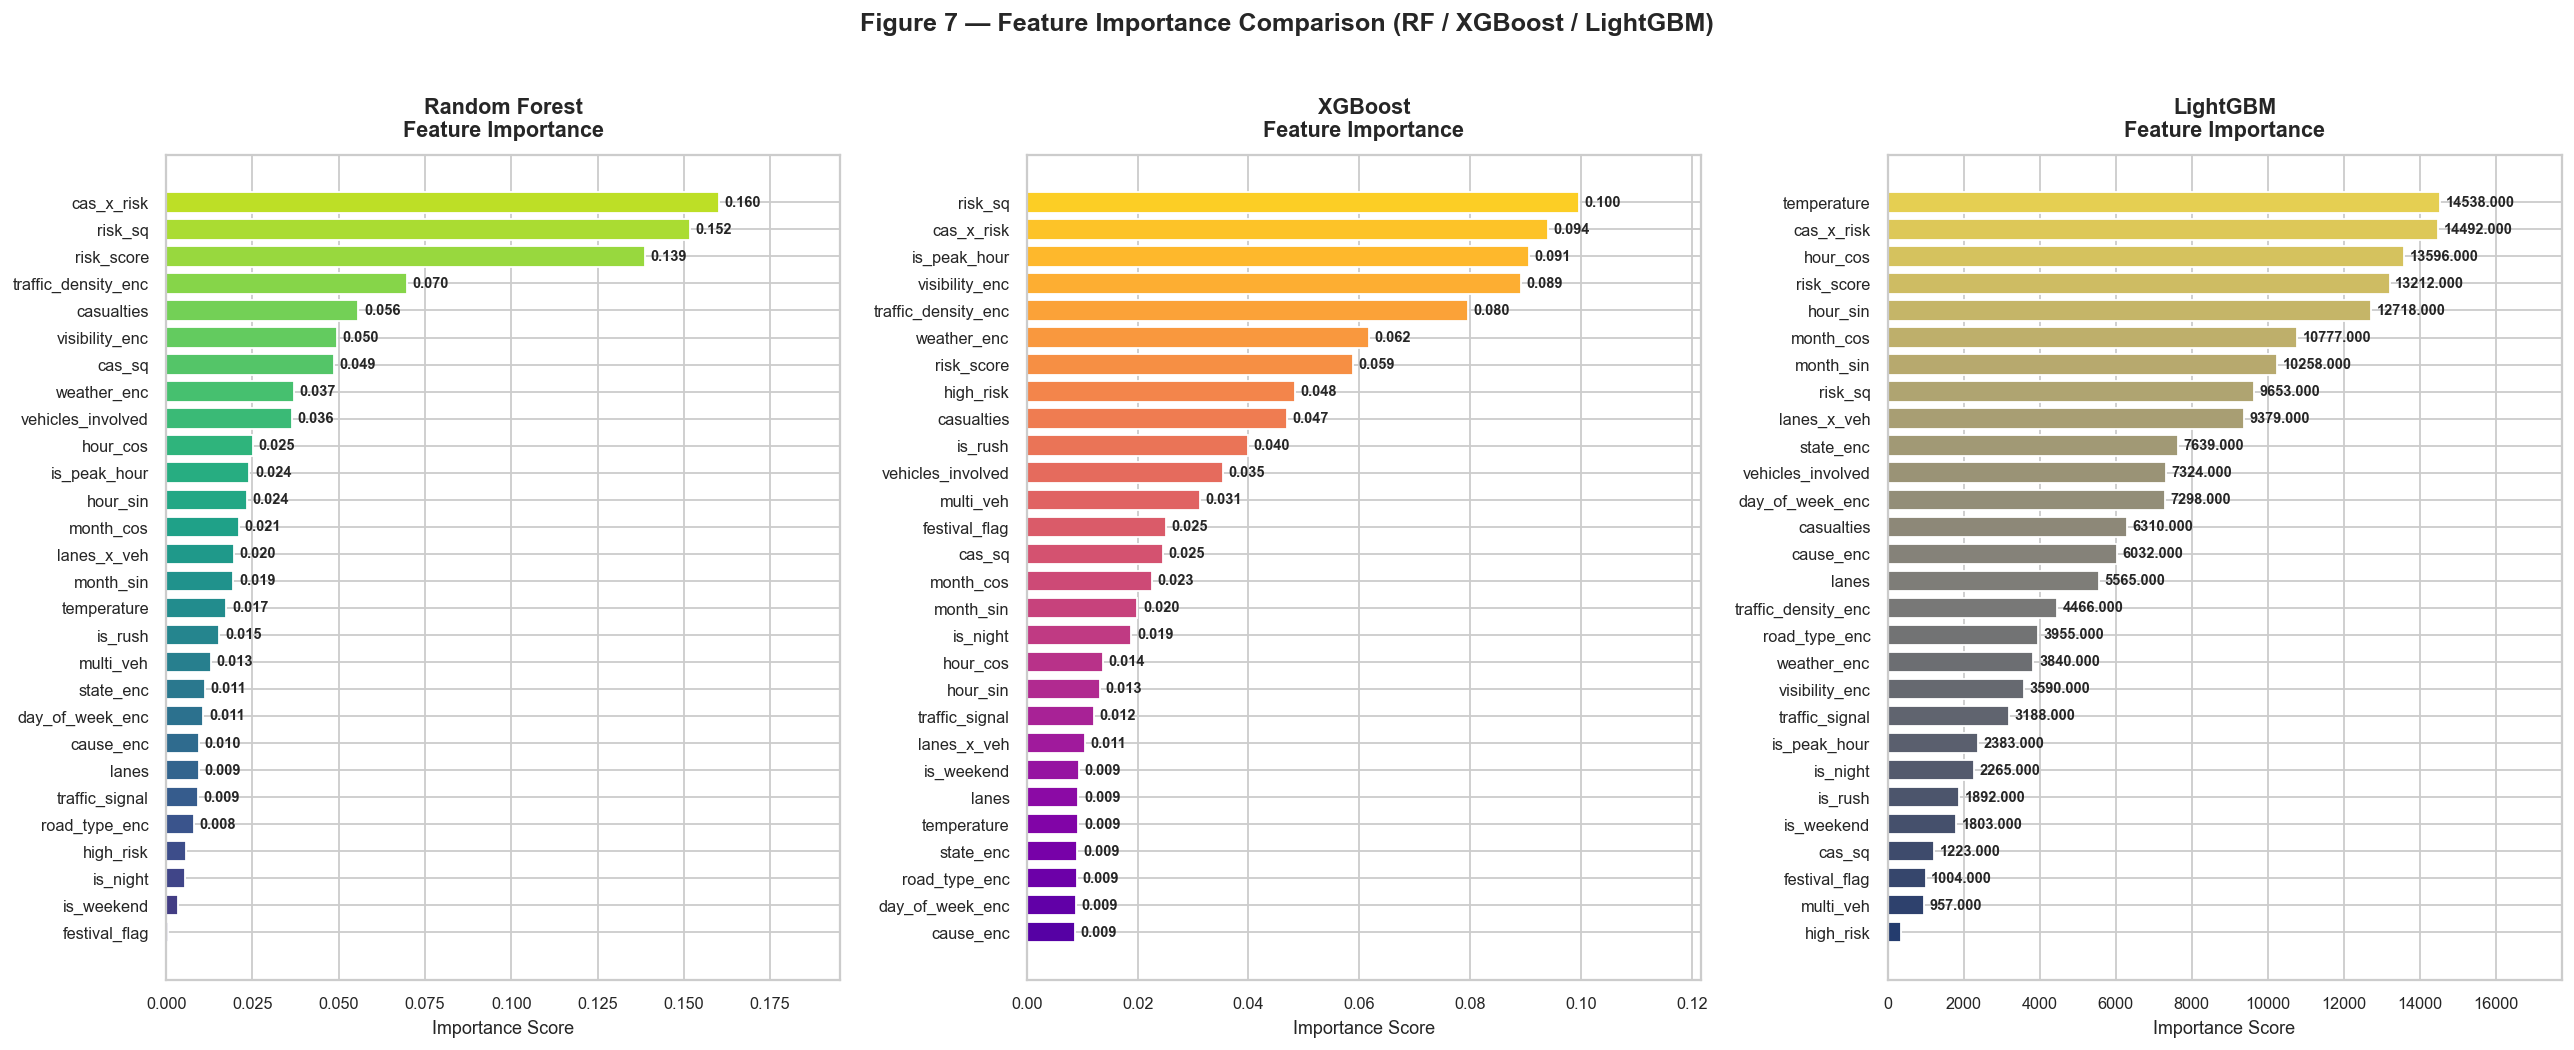


📋 Top 5 Features per Model:


,Random Forest,XGBoost,LightGBM
cas_x_risk,0.1601,0.0941,14492.0000
casualties,0.0557,nan,nan
hour_cos,nan,nan,13596.0000
hour_sin,nan,nan,12718.0000
is_peak_hour,nan,0.0906,nan
risk_score,0.1386,nan,13212.0000
risk_sq,0.1517,0.0997,nan
temperature,nan,nan,14538.0000
traffic_density_enc,0.0699,0.0795,nan
visibility_enc,nan,0.0891,nan



✅  Saved: fig7_feature_importance.png


In [26]:
# ── Extract importances ───────────────────────────────────────
fi_rf  = pd.Series(rf_m.feature_importances_,  index=FEAT_COLS).sort_values(ascending=True)
fi_xgb = pd.Series(xgb_m.feature_importances_, index=FEAT_COLS).sort_values(ascending=True)
fi_lgb = pd.Series(lgb_m.feature_importances_, index=FEAT_COLS).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
combos = [
    (axes[0], fi_rf,  'Random Forest',  'viridis'),
    (axes[1], fi_xgb, 'XGBoost',        'plasma'),
    (axes[2], fi_lgb, 'LightGBM',       'cividis'),
]
for ax, fi, title, cmap in combos:
    clrs = plt.get_cmap(cmap)(np.linspace(0.15, 0.9, len(fi)))
    bars = ax.barh(fi.index, fi.values, color=clrs, edgecolor='white', height=0.75)
    for bar, v in zip(bars, fi.values):
        if v > fi.max()*0.05:
            ax.text(bar.get_width()+fi.max()*0.01, bar.get_y()+bar.get_height()/2,
                    f'{v:.3f}', va='center', fontsize=8, fontweight='bold')
    ax.set_title(f'{title}\nFeature Importance', fontweight='bold', pad=10)
    ax.set_xlabel('Importance Score')
    ax.set_xlim(0, fi.max()*1.22)

plt.suptitle('Figure 7 — Feature Importance Comparison (RF / XGBoost / LightGBM)',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top 5 features across all 3 models ───────────────────────
top5 = pd.DataFrame({
    'Random Forest': fi_rf.sort_values(ascending=False).head(5),
    'XGBoost':       fi_xgb.sort_values(ascending=False).head(5),
    'LightGBM':      fi_lgb.sort_values(ascending=False).head(5),
})
print('\n📋 Top 5 Features per Model:')
display(top5.style.format('{:.4f}').background_gradient(cmap='YlOrRd'))
print('\n✅  Saved: fig7_feature_importance.png')

## 📅 Cell 8 — 2026 Blackspot Prediction & Trend Forecast

**Method:** Per-state linear regression on 2022–2024 accident/fatality trends → project to 2026

**Validation:** Train on 2022–2023 → predict 2024 (actual known) → compute accuracy

**Blackspot Score:** BS = 0.5×D̂ + 0.3×FRd + 0.2×Â

📋 2026 PROJECTED BLACKSPOT RANKINGS


,Rank,State,Pred_Accidents_2026,Pred_Fatalities_2026,Pred_FR_2026,Pred_Avg_Risk_2026,BS_2026,Trend_Accuracy_%
0,1,Maharashtra,496,77,15.62%,0.437,0.861,98.6%
1,2,Delhi,218,41,18.76%,0.487,0.462,98.5%
2,3,Punjab,191,37,19.58%,0.448,0.436,90.3%
3,4,Telangana,197,32,16.20%,0.455,0.276,85.7%
4,5,Tamil Nadu,206,30,14.77%,0.432,0.214,97.3%
5,6,Karnataka,196,29,15.01%,0.434,0.207,96.4%
6,7,West Bengal,199,22,11.03%,0.432,0.005,97.5%


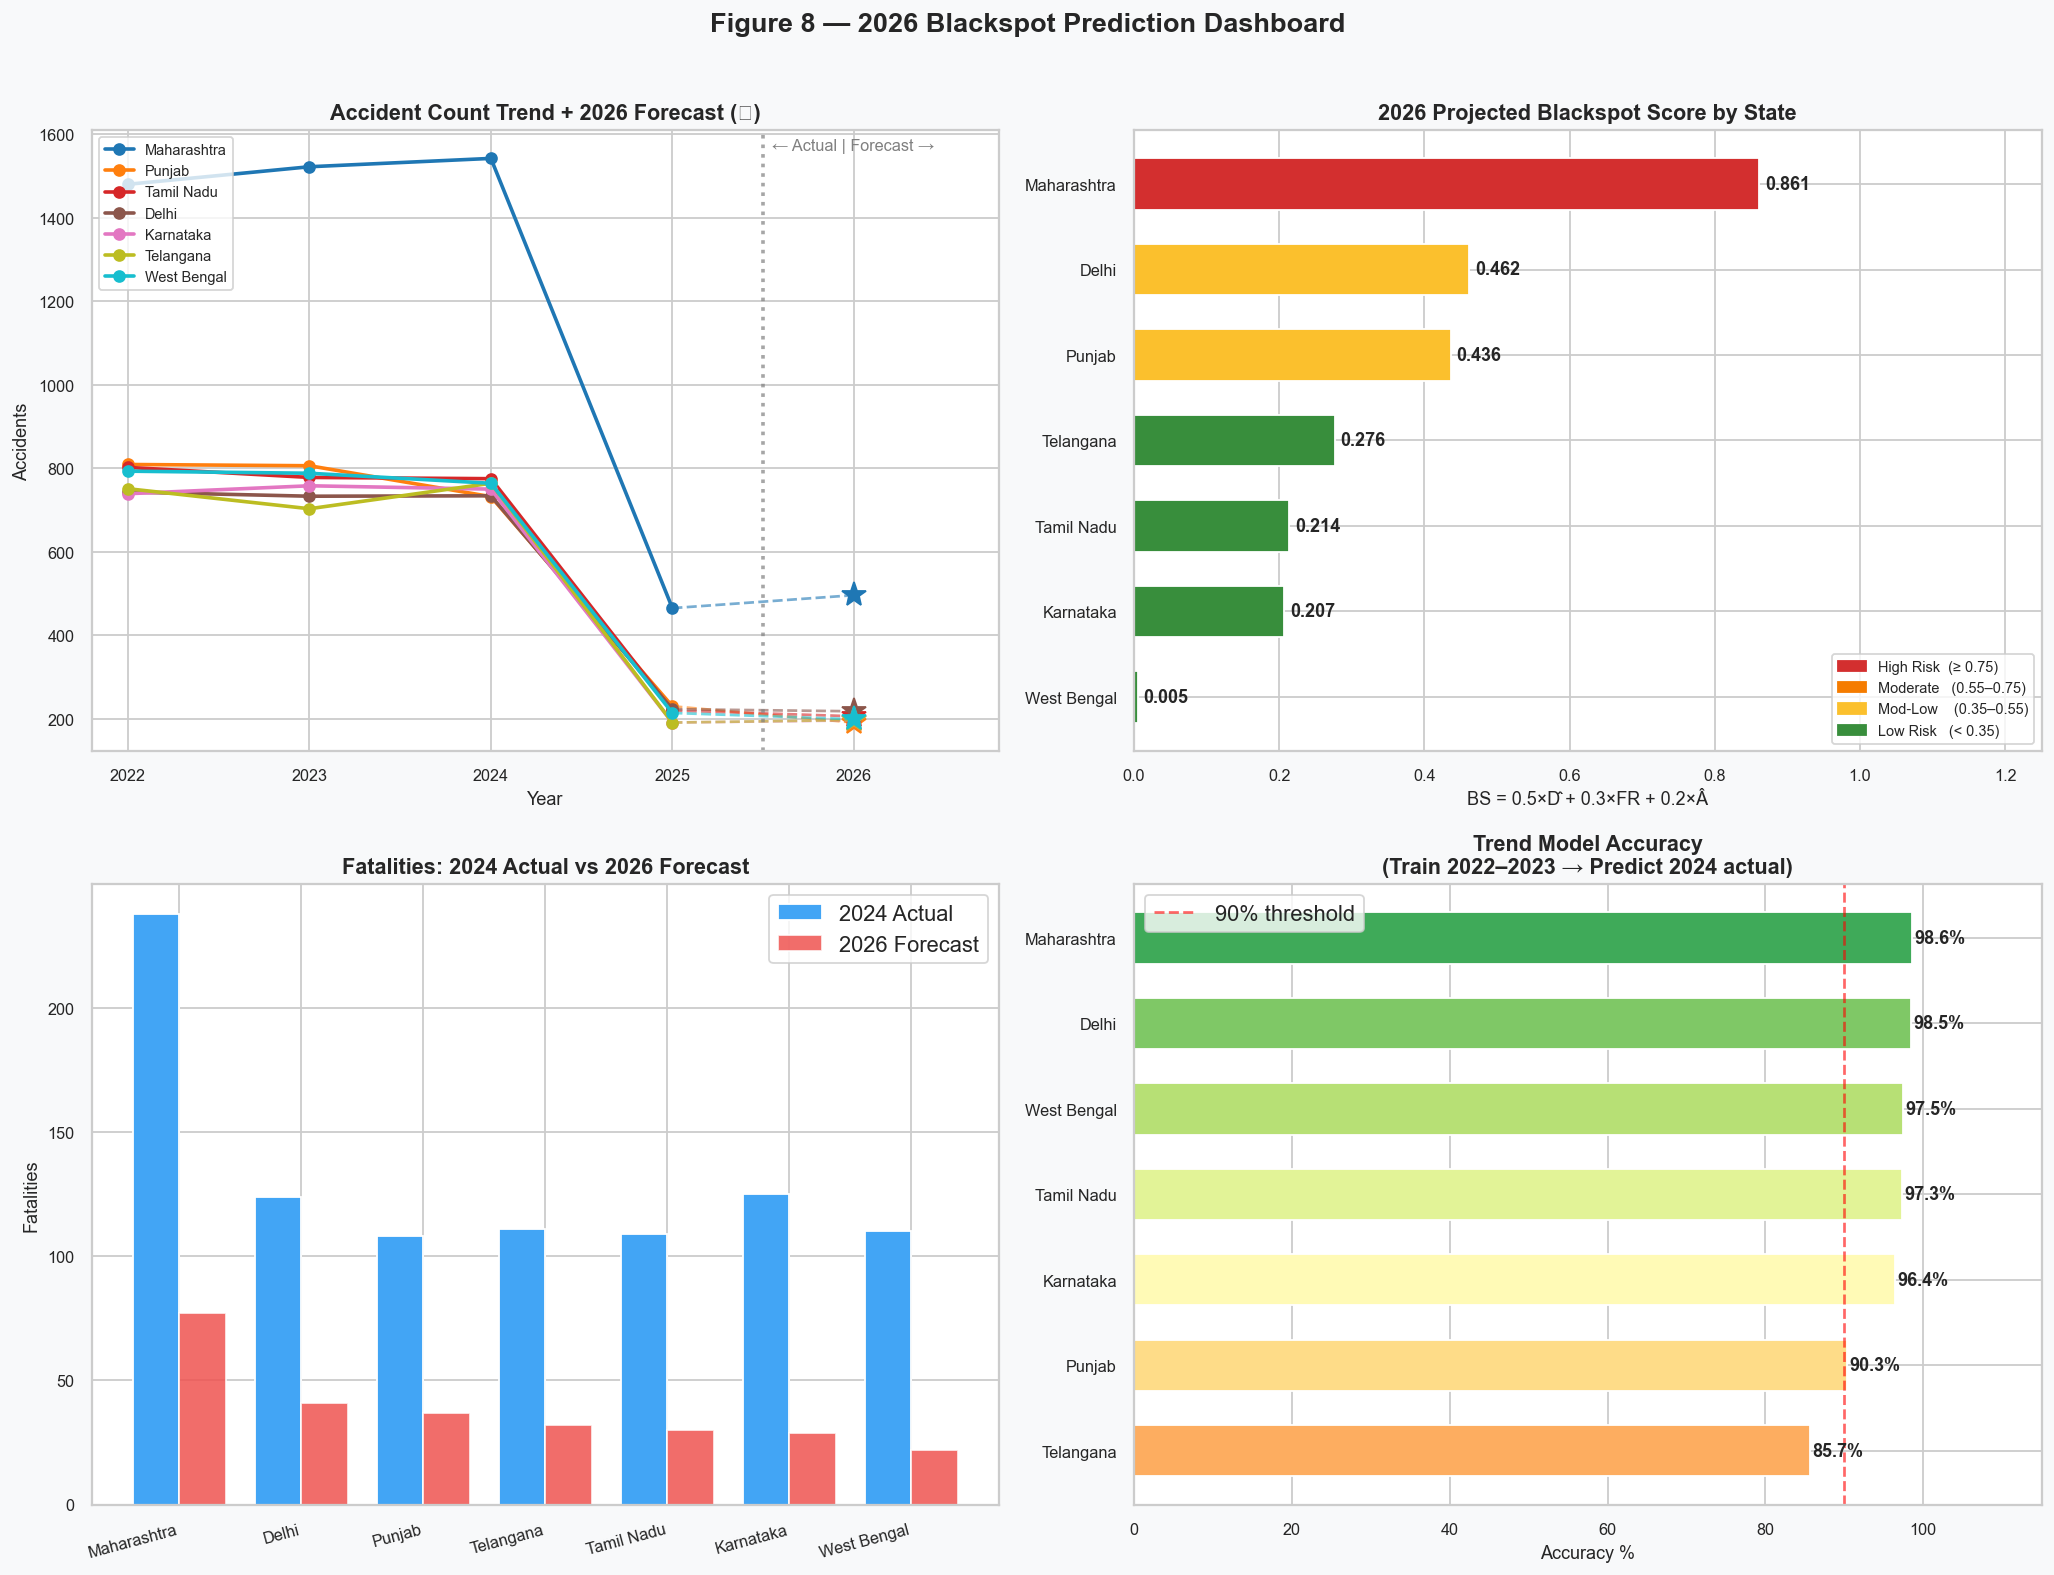


  FINAL PERFORMANCE SUMMARY

  ── ML Classifier (tested on 2025 real data) ──
  #1 Random Forest               Acc=0.440  F1=0.515  F1_major=0.493  AUC=0.763
  #2 Stacking Classifier         Acc=0.476  F1=0.582  F1_major=0.452  AUC=0.757
  #3 LightGBM                    Acc=0.536  F1=0.633  F1_major=0.400  AUC=0.756
  #4 XGBoost                     Acc=0.531  F1=0.630  F1_major=0.425  AUC=0.755
  #5 Logistic Regression         Acc=0.413  F1=0.460  F1_major=0.448  AUC=0.738

  ── 2026 Trend Forecast ──
  Avg trend accuracy   : 94.9%
  Top blackspot state  : Maharashtra (BS=0.861)
  Outputs saved to     : outputs/

  ⚠️  2026 forecasts are projections — no 2026 ground truth yet

📁 All output files:
   fig1_eda_overview.png                         290 KB
   fig2_eda_deepdive.png                         216 KB
   fig3_smote_balance.png                        65 KB
   fig4_roc_curves.png                           142 KB
   fig5_confusion_matrices.png                   103 KB
   fig6_all_me

In [27]:
# ── Per-state yearly aggregates ────────────────────────────────
yr_state = df.groupby(['state','year']).agg(
    accidents=('accident_id','count'),
    fatalities=('target', lambda x: (x==0).sum()),
    avg_risk=('risk_score','mean'),
    avg_casualties=('casualties','mean')
).reset_index()
yr_state['fr'] = yr_state['fatalities']/yr_state['accidents']*100

# ── Project 2026 + validate on 2024 ───────────────────────────
proj = []
for state in df['state'].unique():
    sdf = yr_state[yr_state['state']==state].sort_values('year')
    if len(sdf) < 3: continue
    yr_vals = sdf['year'].values.reshape(-1,1)

    def proj_val(col, yr=2026):
        return max(LinearRegression().fit(yr_vals, sdf[col]).predict([[yr]])[0], 0)

    acc26 = proj_val('accidents')
    fat26 = proj_val('fatalities')
    rsk26 = float(np.clip(proj_val('avg_risk'), 0, 1))
    fr26  = (fat26/acc26*100) if acc26>0 else 0

    # Validation: train 2022-2023 → predict 2024
    sdf_tr  = sdf[sdf['year']<=2023]
    sdf_act = sdf[sdf['year']==2024]
    trend_acc = None
    if len(sdf_tr)>=2 and len(sdf_act)>0:
        pred24 = LinearRegression().fit(
            sdf_tr[['year']], sdf_tr['accidents']).predict([[2024]])[0]
        act24  = sdf_act['accidents'].values[0]
        trend_acc = round(100 - abs(pred24-act24)/act24*100, 1)

    proj.append({'State':state,
                 'Pred_Accidents_2026':int(acc26),
                 'Pred_Fatalities_2026':int(fat26),
                 'Pred_FR_2026':round(fr26,2),
                 'Pred_Avg_Risk_2026':round(rsk26,3),
                 'Trend_Accuracy_%':trend_acc})

proj_df = pd.DataFrame(proj)
mms = MinMaxScaler()
proj_df['D_norm']  = mms.fit_transform(proj_df[['Pred_Fatalities_2026']])
proj_df['FR_norm'] = mms.fit_transform(proj_df[['Pred_FR_2026']])
proj_df['A_norm']  = mms.fit_transform(proj_df[['Pred_Accidents_2026']])
proj_df['BS_2026'] = (0.5*proj_df['D_norm'] +
                      0.3*proj_df['FR_norm'] +
                      0.2*proj_df['A_norm'])
proj_df = proj_df.sort_values('BS_2026', ascending=False).reset_index(drop=True)
proj_df['Rank'] = proj_df.index+1

print('📋 2026 PROJECTED BLACKSPOT RANKINGS')
display(proj_df[['Rank','State','Pred_Accidents_2026','Pred_Fatalities_2026',
                 'Pred_FR_2026','Pred_Avg_Risk_2026','BS_2026','Trend_Accuracy_%']]
          .style
          .format({'Pred_Accidents_2026':'{:,.0f}','Pred_Fatalities_2026':'{:,.0f}',
                   'Pred_FR_2026':'{:.2f}%','Pred_Avg_Risk_2026':'{:.3f}',
                   'BS_2026':'{:.3f}','Trend_Accuracy_%':'{:.1f}%'})
          .background_gradient(subset=['BS_2026'], cmap='RdYlGn_r')
          .background_gradient(subset=['Trend_Accuracy_%'], cmap='Greens'))

# ── Figure 8: 4-panel 2026 dashboard ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='#f8f9fa')
fig.suptitle('Figure 8 — 2026 Blackspot Prediction Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

# 8A: Trend lines per state
colors_s = plt.cm.tab10(np.linspace(0,1,df['state'].nunique()))
ax_a = axes[0,0]
for state, color in zip(df['state'].unique(), colors_s):
    sdf = yr_state[yr_state['state']==state].sort_values('year')
    ax_a.plot(sdf['year'], sdf['accidents'], 'o-', color=color, lw=2, ms=6, label=state)
    p26 = proj_df[proj_df['State']==state]['Pred_Accidents_2026'].values
    if len(p26):
        last_yr  = sdf['year'].max()
        last_val = sdf[sdf['year']==last_yr]['accidents'].values[0]
        ax_a.plot([last_yr,2026],[last_val,p26[0]],'--',color=color,lw=1.5,alpha=0.6)
        ax_a.plot(2026, p26[0], '*', ms=14, color=color)
ax_a.axvline(2025.5,color='gray',ls=':',lw=2,alpha=0.7)
ax_a.text(2025.55, ax_a.get_ylim()[1]*0.97,'← Actual | Forecast →',
          fontsize=9, color='gray')
ax_a.set_title('Accident Count Trend + 2026 Forecast (★)', fontweight='bold')
ax_a.set_xlabel('Year'); ax_a.set_ylabel('Accidents')
ax_a.legend(fontsize=8, loc='upper left')
ax_a.set_xlim(2021.8, 2026.8)

# 8B: 2026 Blackspot bar chart
ax_b = axes[0,1]
proj_sorted = proj_df.sort_values('BS_2026')
bar_clrs = [risk_color(v) for v in proj_sorted['BS_2026']]
bars_b = ax_b.barh(proj_sorted['State'], proj_sorted['BS_2026'],
                    color=bar_clrs, edgecolor='white', height=0.6)
for bar, val in zip(bars_b, proj_sorted['BS_2026']):
    ax_b.text(bar.get_width()+0.008, bar.get_y()+bar.get_height()/2,
              f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#d32f2f', label='High Risk  (≥ 0.75)'),
    mpatches.Patch(color='#f57c00', label='Moderate   (0.55–0.75)'),
    mpatches.Patch(color='#fbc02d', label='Mod-Low    (0.35–0.55)'),
    mpatches.Patch(color='#388e3c', label='Low Risk   (< 0.35)'),
]
ax_b.legend(handles=legend_patches, fontsize=8, loc='lower right')
ax_b.set_title('2026 Projected Blackspot Score by State', fontweight='bold')
ax_b.set_xlabel('BS = 0.5×D̂ + 0.3×FR + 0.2×Â')
ax_b.set_xlim(0, 1.25)

# 8C: Predicted fatalities 2026 vs 2024 actual
ax_c = axes[1,0]
actual_2024 = yr_state[yr_state['year']==2024].groupby('state')['fatalities'].sum().reset_index()
comp = proj_df[['State','Pred_Fatalities_2026']].merge(
    actual_2024.rename(columns={'state':'State','fatalities':'Actual_2024'}), on='State')
x = np.arange(len(comp)); w = 0.38
ax_c.bar(x-w/2, comp['Actual_2024'],   w, label='2024 Actual',       color='#42a5f5', edgecolor='white')
ax_c.bar(x+w/2, comp['Pred_Fatalities_2026'], w, label='2026 Forecast', color='#ef5350', edgecolor='white', alpha=0.85)
ax_c.set_xticks(x); ax_c.set_xticklabels(comp['State'], rotation=15, ha='right')
ax_c.set_title('Fatalities: 2024 Actual vs 2026 Forecast', fontweight='bold')
ax_c.set_ylabel('Fatalities'); ax_c.legend()

# 8D: Trend validation accuracy
ax_d = axes[1,1]
val_acc = proj_df.dropna(subset=['Trend_Accuracy_%']).sort_values('Trend_Accuracy_%')
clrs_v = plt.cm.RdYlGn(np.linspace(0.3,0.85,len(val_acc)))
bars_d = ax_d.barh(val_acc['State'], val_acc['Trend_Accuracy_%'],
                    color=clrs_v, edgecolor='white', height=0.6)
for bar, v in zip(bars_d, val_acc['Trend_Accuracy_%']):
    ax_d.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
              f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
ax_d.axvline(90, color='red', ls='--', lw=1.5, alpha=0.6, label='90% threshold')
ax_d.set_title('Trend Model Accuracy\n(Train 2022–2023 → Predict 2024 actual)',
               fontweight='bold')
ax_d.set_xlabel('Accuracy %'); ax_d.set_xlim(0, 115)
ax_d.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig8_2026_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final Summary ──────────────────────────────────────────────
avg_trend = proj_df['Trend_Accuracy_%'].dropna().mean()
print('\n' + '='*65)
print('  FINAL PERFORMANCE SUMMARY')
print('='*65)
print(f'\n  ── ML Classifier (tested on 2025 real data) ──')
for _, row in res_df.iterrows():
    print(f'  #{int(row["Rank"])} {row["Model"]:<26}  '
          f'Acc={row["Accuracy"]:.3f}  F1={row["F1_Macro"]:.3f}  '
          f'F1_major={row["F1_Major"]:.3f}  AUC={row["AUC_OVR"]:.3f}')
print(f'\n  ── 2026 Trend Forecast ──')
print(f'  Avg trend accuracy   : {avg_trend:.1f}%')
print(f'  Top blackspot state  : {proj_df.iloc[0]["State"]} (BS={proj_df.iloc[0]["BS_2026"]:.3f})')
print(f'  Outputs saved to     : outputs/')
print(f'\n  ⚠️  2026 forecasts are projections — no 2026 ground truth yet')
print('='*65)

print('\n📁 All output files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}')/1024
    print(f'   {f:<45} {size:.0f} KB')